# Final Task 2: Loss-Curve Prediction

本 notebook 分成三部分，展示顺序如下：

1. **主任务复现**：复现 Tissue2024 和 LuoMPL，在 `cosine` 上拟合，在 `WSD` 上测试。
2. **迁移拓展实验**：仍然只使用复现基线，测试 `cosine`、`WSD`、`8-1-1` 三种调度之间的 6 种有向迁移。
3. **方法发展**：加入我们提出的损失曲线拟合策略，并和复现基线比较。

先运行脚本生成全部结果，然后按三部分依次查看。

In [57]:
import pandas as pd

data = pd.read_pickle('loss curves/gpt_loss+lrs.pkl')
list(data.keys())

['M:100M_gpt_D:20B_scheduler:811_rope',
 'M:100M_gpt_D:20B_scheduler:wsd_rope',
 'M:100M_gpt_D:20B_scheduler:cosine_rope']

In [58]:
# 运行脚本生成主任务、迁移拓展和方法发展结果。
%run final_task2_reproduction.py

[cosine_fit] Fitting Tissue2024 on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting LuoMPL on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev1-EffectiveTime on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev2-StepResidual on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev3-EffectiveResidual on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev4-VelocityMatched on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev5-HybridTissueMPL on cosine...


/Users/dyx/Desktop/深度学习理论选讲/final_task2_reproduction.py:585: RuntimeWarning: overflow encountered in power
/Users/dyx/Desktop/深度学习理论选讲/final_task2_reproduction.py:585: RuntimeWarning: overflow encountered in multiply


  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev6-CurvatureMatched on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev7-PowerExponential on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev8-TimeEnsemble on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev9-TissueVelocity on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev10-LuoMPLVelocity on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[cosine_fit] Fitting Dev11-PowerExpVelocity on cosine...
  predicting cosine
  predicting wsd
  predicting 811
[wsd_fit] Fitting Tissue2024 on wsd...
  predicting cosine
  predicting wsd
  predicting 811
[wsd_fit] Fitting LuoMPL on wsd...
  predicting cosine
  predicting wsd
  predicting 811
[wsd_fit] Fitting Dev1-EffectiveTime on wsd...
  predicting cosine
  predicting wsd
  predicting 811
[wsd_fit]

/Users/dyx/Desktop/深度学习理论选讲/final_task2_reproduction.py:136: RuntimeWarning: overflow encountered in power
  return np.maximum(l0 + a * s1 ** (-alpha) - c * s2, 1e-9)


  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting LuoMPL on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev1-EffectiveTime on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev2-StepResidual on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev3-EffectiveResidual on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev4-VelocityMatched on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev5-HybridTissueMPL on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev6-CurvatureMatched on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev7-PowerExponential on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev8-TimeEnsemble on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev9-TissueVelocity

/Users/dyx/Desktop/深度学习理论选讲/final_task2_reproduction.py:170: RuntimeWarning: overflow encountered in power
  # only allows fitting on one cosine curve, so we keep the MPL shape fixed
/Users/dyx/Desktop/深度学习理论选讲/final_task2_reproduction.py:102: RuntimeWarning: invalid value encountered in subtract
  for i, d in enumerate(delta):


  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev10-LuoMPLVelocity on 811...
  predicting cosine
  predicting wsd
  predicting 811
[811_fit] Fitting Dev11-PowerExpVelocity on 811...
  predicting cosine
  predicting wsd
  predicting 811
Writing plots...
Writing markdown report...
     mae     rmse     mape  worst_relative_error        r2  final_abs_error  final_relative_error experiment                  model fit_scheduler target      role  selected_velocity_weight        direction
0.037306 0.049025 0.012861              0.067337  0.964941         0.021322              0.008058 cosine_fit             Tissue2024        cosine cosine fit_check                       NaN cosine -> cosine
0.056787 0.069550 0.019611              0.080386  0.922965         0.029700              0.011268 cosine_fit             Tissue2024        cosine    wsd  transfer                       NaN    cosine -> wsd
0.057466 0.070724 0.019822              0.081525  0.921926         0.023655 

## Part 1: 主任务复现

这里只展示复现基线 `Tissue2024` 和 `LuoMPL`。`cosine -> cosine` 是拟合检查，`cosine -> WSD` 是原始任务要求的预测结果。

In [59]:
main_metrics = pd.read_csv('task2_outputs/task2_main_metrics.csv')
main_metrics

,mae,rmse,mape,worst_relative_error,r2,final_abs_error,final_relative_error,experiment,model,fit_scheduler,target,role,selected_velocity_weight,direction
0,0.037306,0.049025,0.012861,0.067337,0.964941,0.021322,0.008058,cosine_fit,Tissue2024,cosine,cosine,fit_check,NaN,cosine -> cosine
1,0.056787,0.069550,0.019611,0.080386,0.922965,0.029700,0.011268,cosine_fit,Tissue2024,cosine,wsd,transfer,NaN,cosine -> wsd
2,0.039168,0.051882,0.013471,0.071861,0.960736,0.036646,0.013849,cosine_fit,LuoMPL,cosine,cosine,fit_check,NaN,cosine -> cosine
3,0.056016,0.068751,0.019314,0.077749,0.924725,0.004980,0.001889,cosine_fit,LuoMPL,cosine,wsd,transfer,NaN,cosine -> wsd


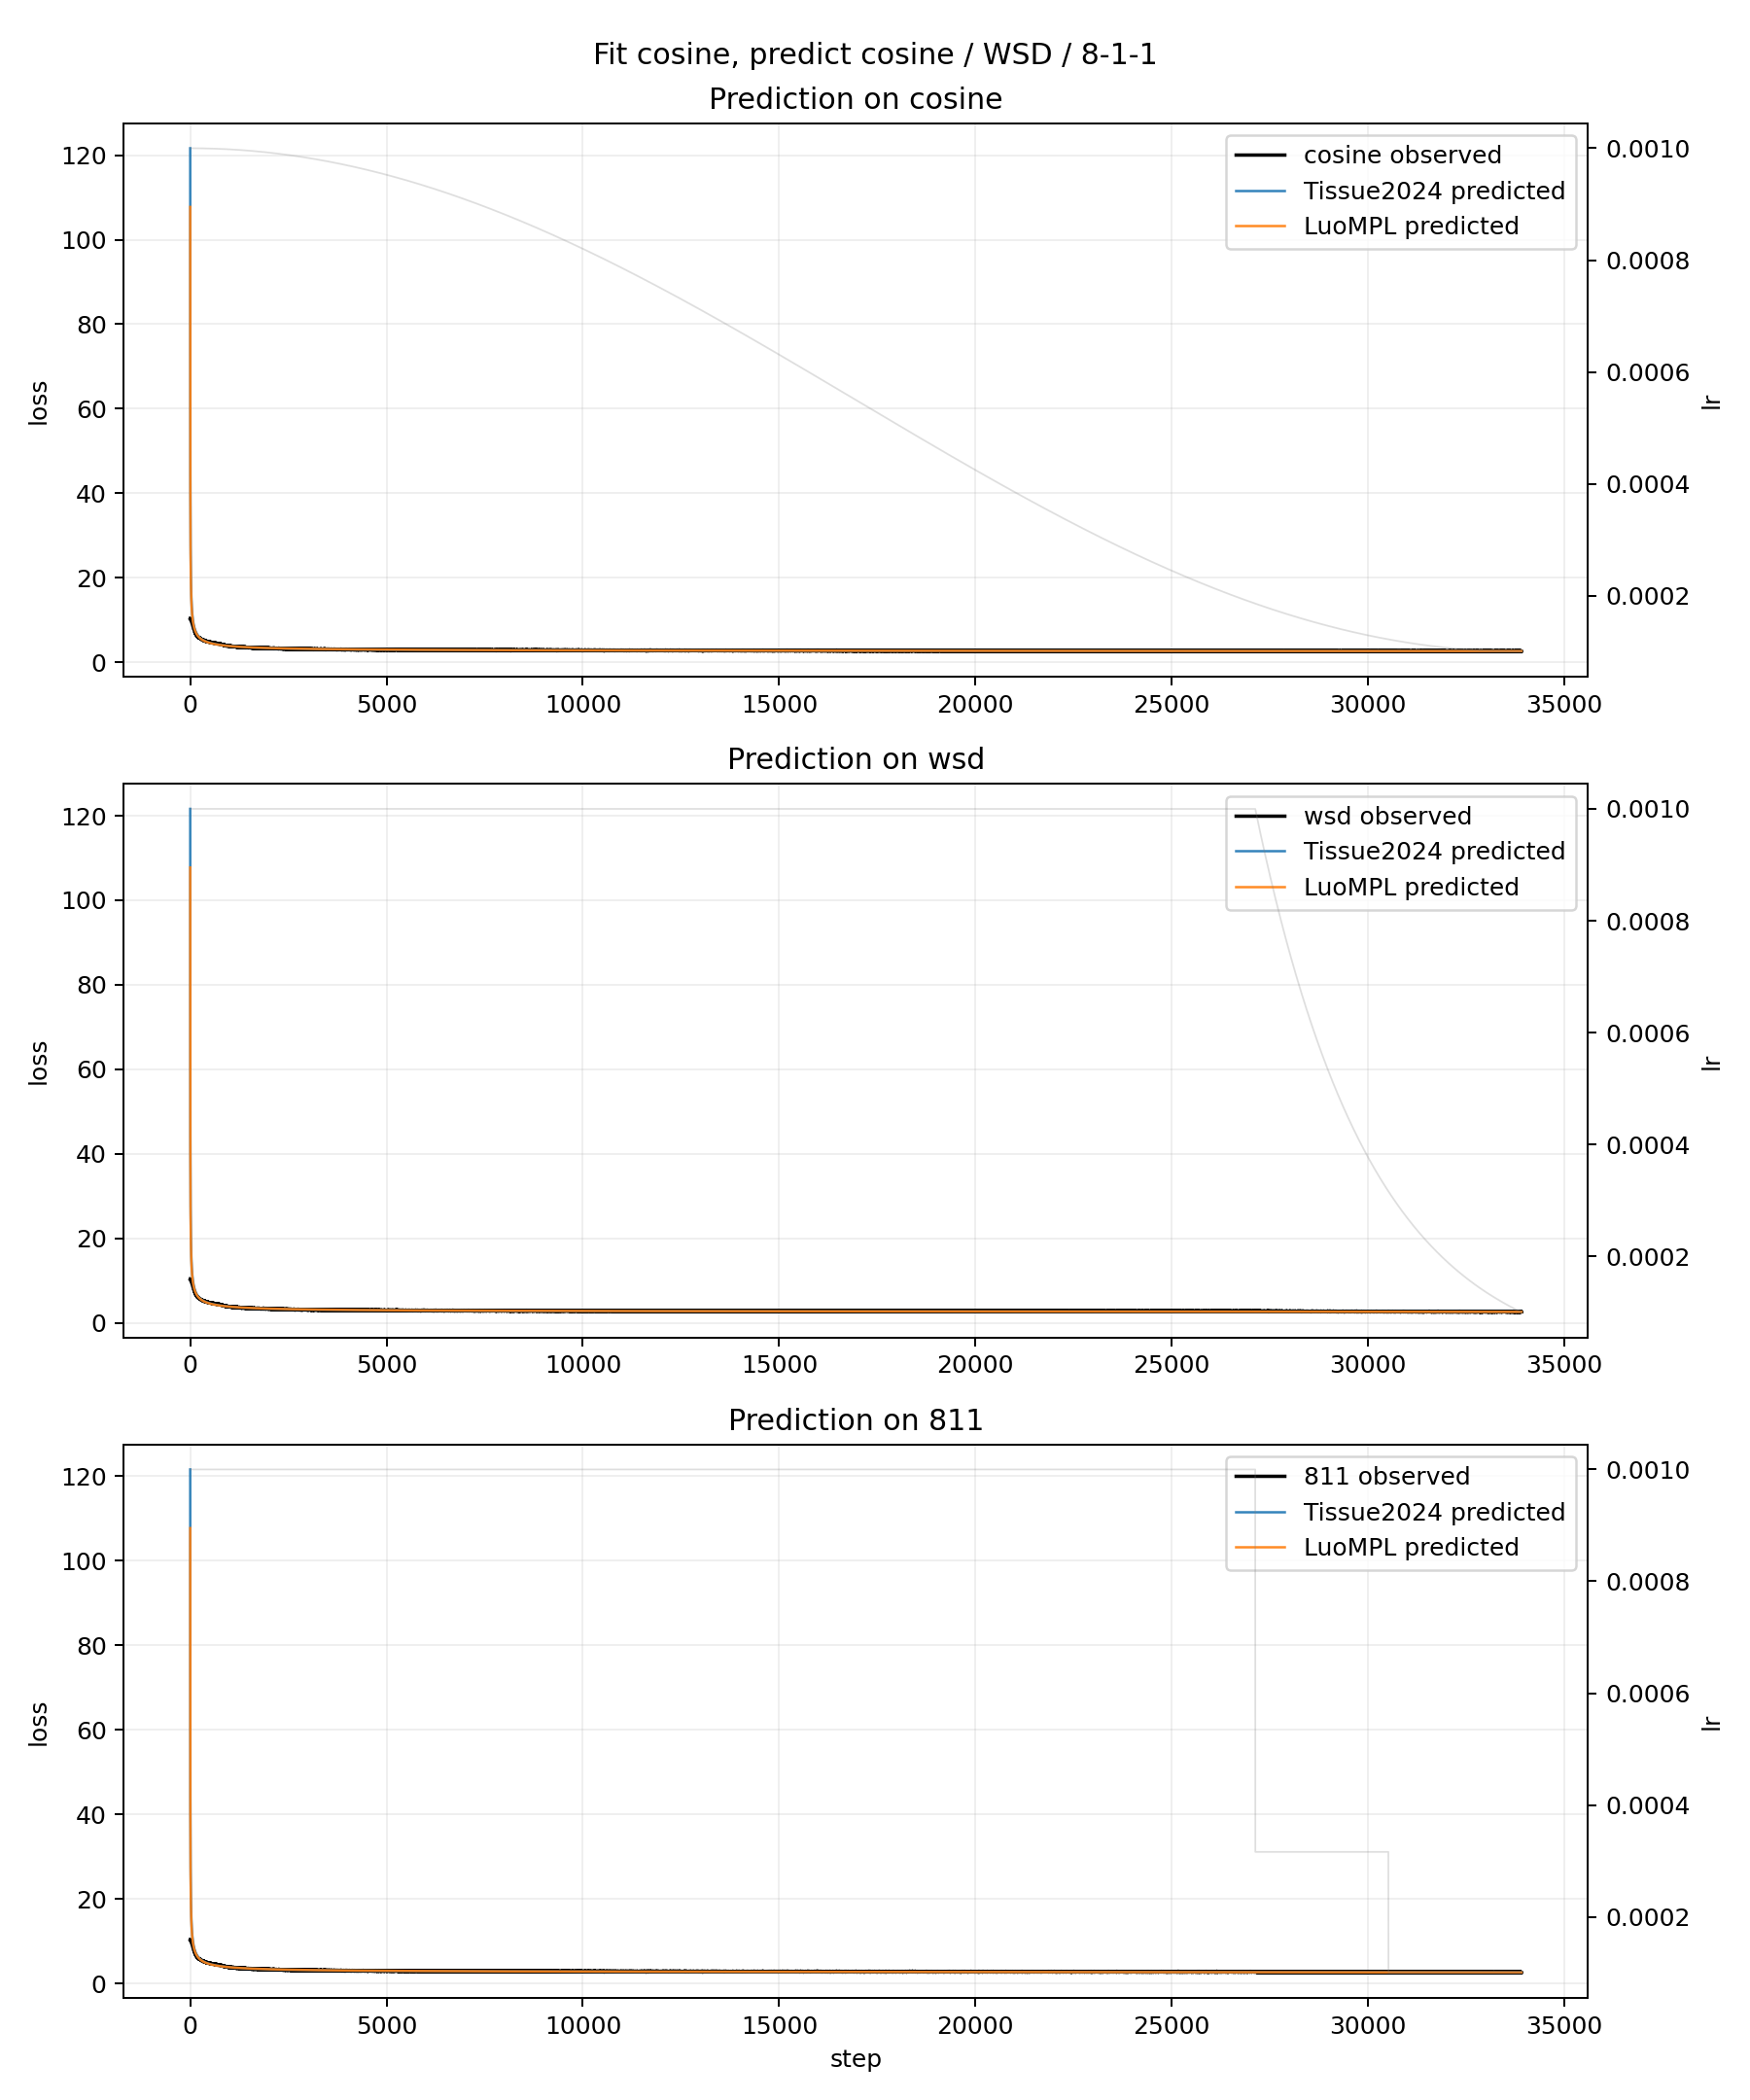

In [60]:
from IPython.display import Image, display

display(Image('task2_outputs/task2_cosine_fit_predictions.png'))

## Part 2: 迁移拓展实验

这一部分仍然只比较复现基线，用于回答三种调度之间哪一种迁移方向最好。

In [61]:
extension_metrics = pd.read_csv('task2_outputs/task2_extension_metrics.csv')
extension_metrics

,mae,rmse,mape,worst_relative_error,r2,final_abs_error,final_relative_error,experiment,model,fit_scheduler,target,role,selected_velocity_weight,direction
0,0.056787,0.069550,0.019611,0.080386,0.922965,0.029700,0.011268,cosine_fit,Tissue2024,cosine,wsd,transfer,NaN,cosine -> wsd
1,0.057466,0.070724,0.019822,0.081525,0.921926,0.023655,0.008959,cosine_fit,Tissue2024,cosine,811,transfer,NaN,cosine -> 811
2,0.056016,0.068751,0.019314,0.077749,0.924725,0.004980,0.001889,cosine_fit,LuoMPL,cosine,wsd,transfer,NaN,cosine -> wsd
3,0.057161,0.070145,0.019704,0.078891,0.923199,0.006039,0.002287,cosine_fit,LuoMPL,cosine,811,transfer,NaN,cosine -> 811
4,0.045124,0.065377,0.015405,0.107109,0.937654,0.052472,0.019829,wsd_fit,Tissue2024,wsd,cosine,transfer,NaN,wsd -> cosine
5,0.044580,0.065011,0.014966,0.107762,0.934029,0.016234,0.006148,wsd_fit,Tissue2024,wsd,811,transfer,NaN,wsd -> 811
6,0.049812,0.069537,0.017168,0.107816,0.929467,0.078384,0.029622,wsd_fit,LuoMPL,wsd,cosine,transfer,NaN,wsd -> cosine
7,0.044810,0.065366,0.015042,0.108460,0.933307,0.033329,0.012623,wsd_fit,LuoMPL,wsd,811,transfer,NaN,wsd -> 811
8,0.051199,0.070333,0.017670,0.105733,0.927845,0.080201,0.030308,811_fit,Tissue2024,811,cosine,transfer,NaN,811 -> cosine
9,0.045598,0.065372,0.015332,0.103843,0.931942,0.033833,0.012836,811_fit,Tissue2024,811,wsd,transfer,NaN,811 -> wsd


In [62]:
ranking = pd.read_csv('task2_outputs/task2_transfer_ranking.csv')
ranking

,direction,fit_scheduler,target,mean_mape,mean_rmse,mean_mae,mean_final_relative_error
0,wsd -> 811,wsd,811,0.015004,0.065189,0.044695,0.009386
1,811 -> wsd,811,wsd,0.015324,0.065364,0.045577,0.012811
2,wsd -> cosine,wsd,cosine,0.016287,0.067457,0.047468,0.024725
3,811 -> cosine,811,cosine,0.017615,0.070212,0.051053,0.030050
4,cosine -> wsd,cosine,wsd,0.019462,0.069151,0.056401,0.006579
5,cosine -> 811,cosine,811,0.019763,0.070434,0.057313,0.005623


In [63]:
import json

with open('task2_outputs/task2_best_transfer.json', encoding='utf-8') as f:
    best_transfer = json.load(f)
best_transfer

{'selection_metric': 'mape',
 'best_direction_average_over_models': {'direction': 'wsd -> 811',
  'fit_scheduler': 'wsd',
  'target': '811',
  'mean_mape': 0.01500401159131243,
  'mean_rmse': 0.06518855227363476,
  'mean_mae': 0.044694661167997286,
  'mean_final_relative_error': 0.009385737279779864},
 'best_direction_per_model': [{'model': 'Tissue2024',
   'direction': 'wsd -> 811',
   'fit_scheduler': 'wsd',
   'target': '811',
   'mape': 0.014965678951259088,
   'rmse': 0.0650111043926768,
   'mae': 0.044579590338446336,
   'final_relative_error': 0.00614839236002469},
  {'model': 'LuoMPL',
   'direction': 'wsd -> 811',
   'fit_scheduler': 'wsd',
   'target': '811',
   'mape': 0.015042344231365771,
   'rmse': 0.06536600015459275,
   'mae': 0.04480973199754824,
   'final_relative_error': 0.01262308219953504}]}

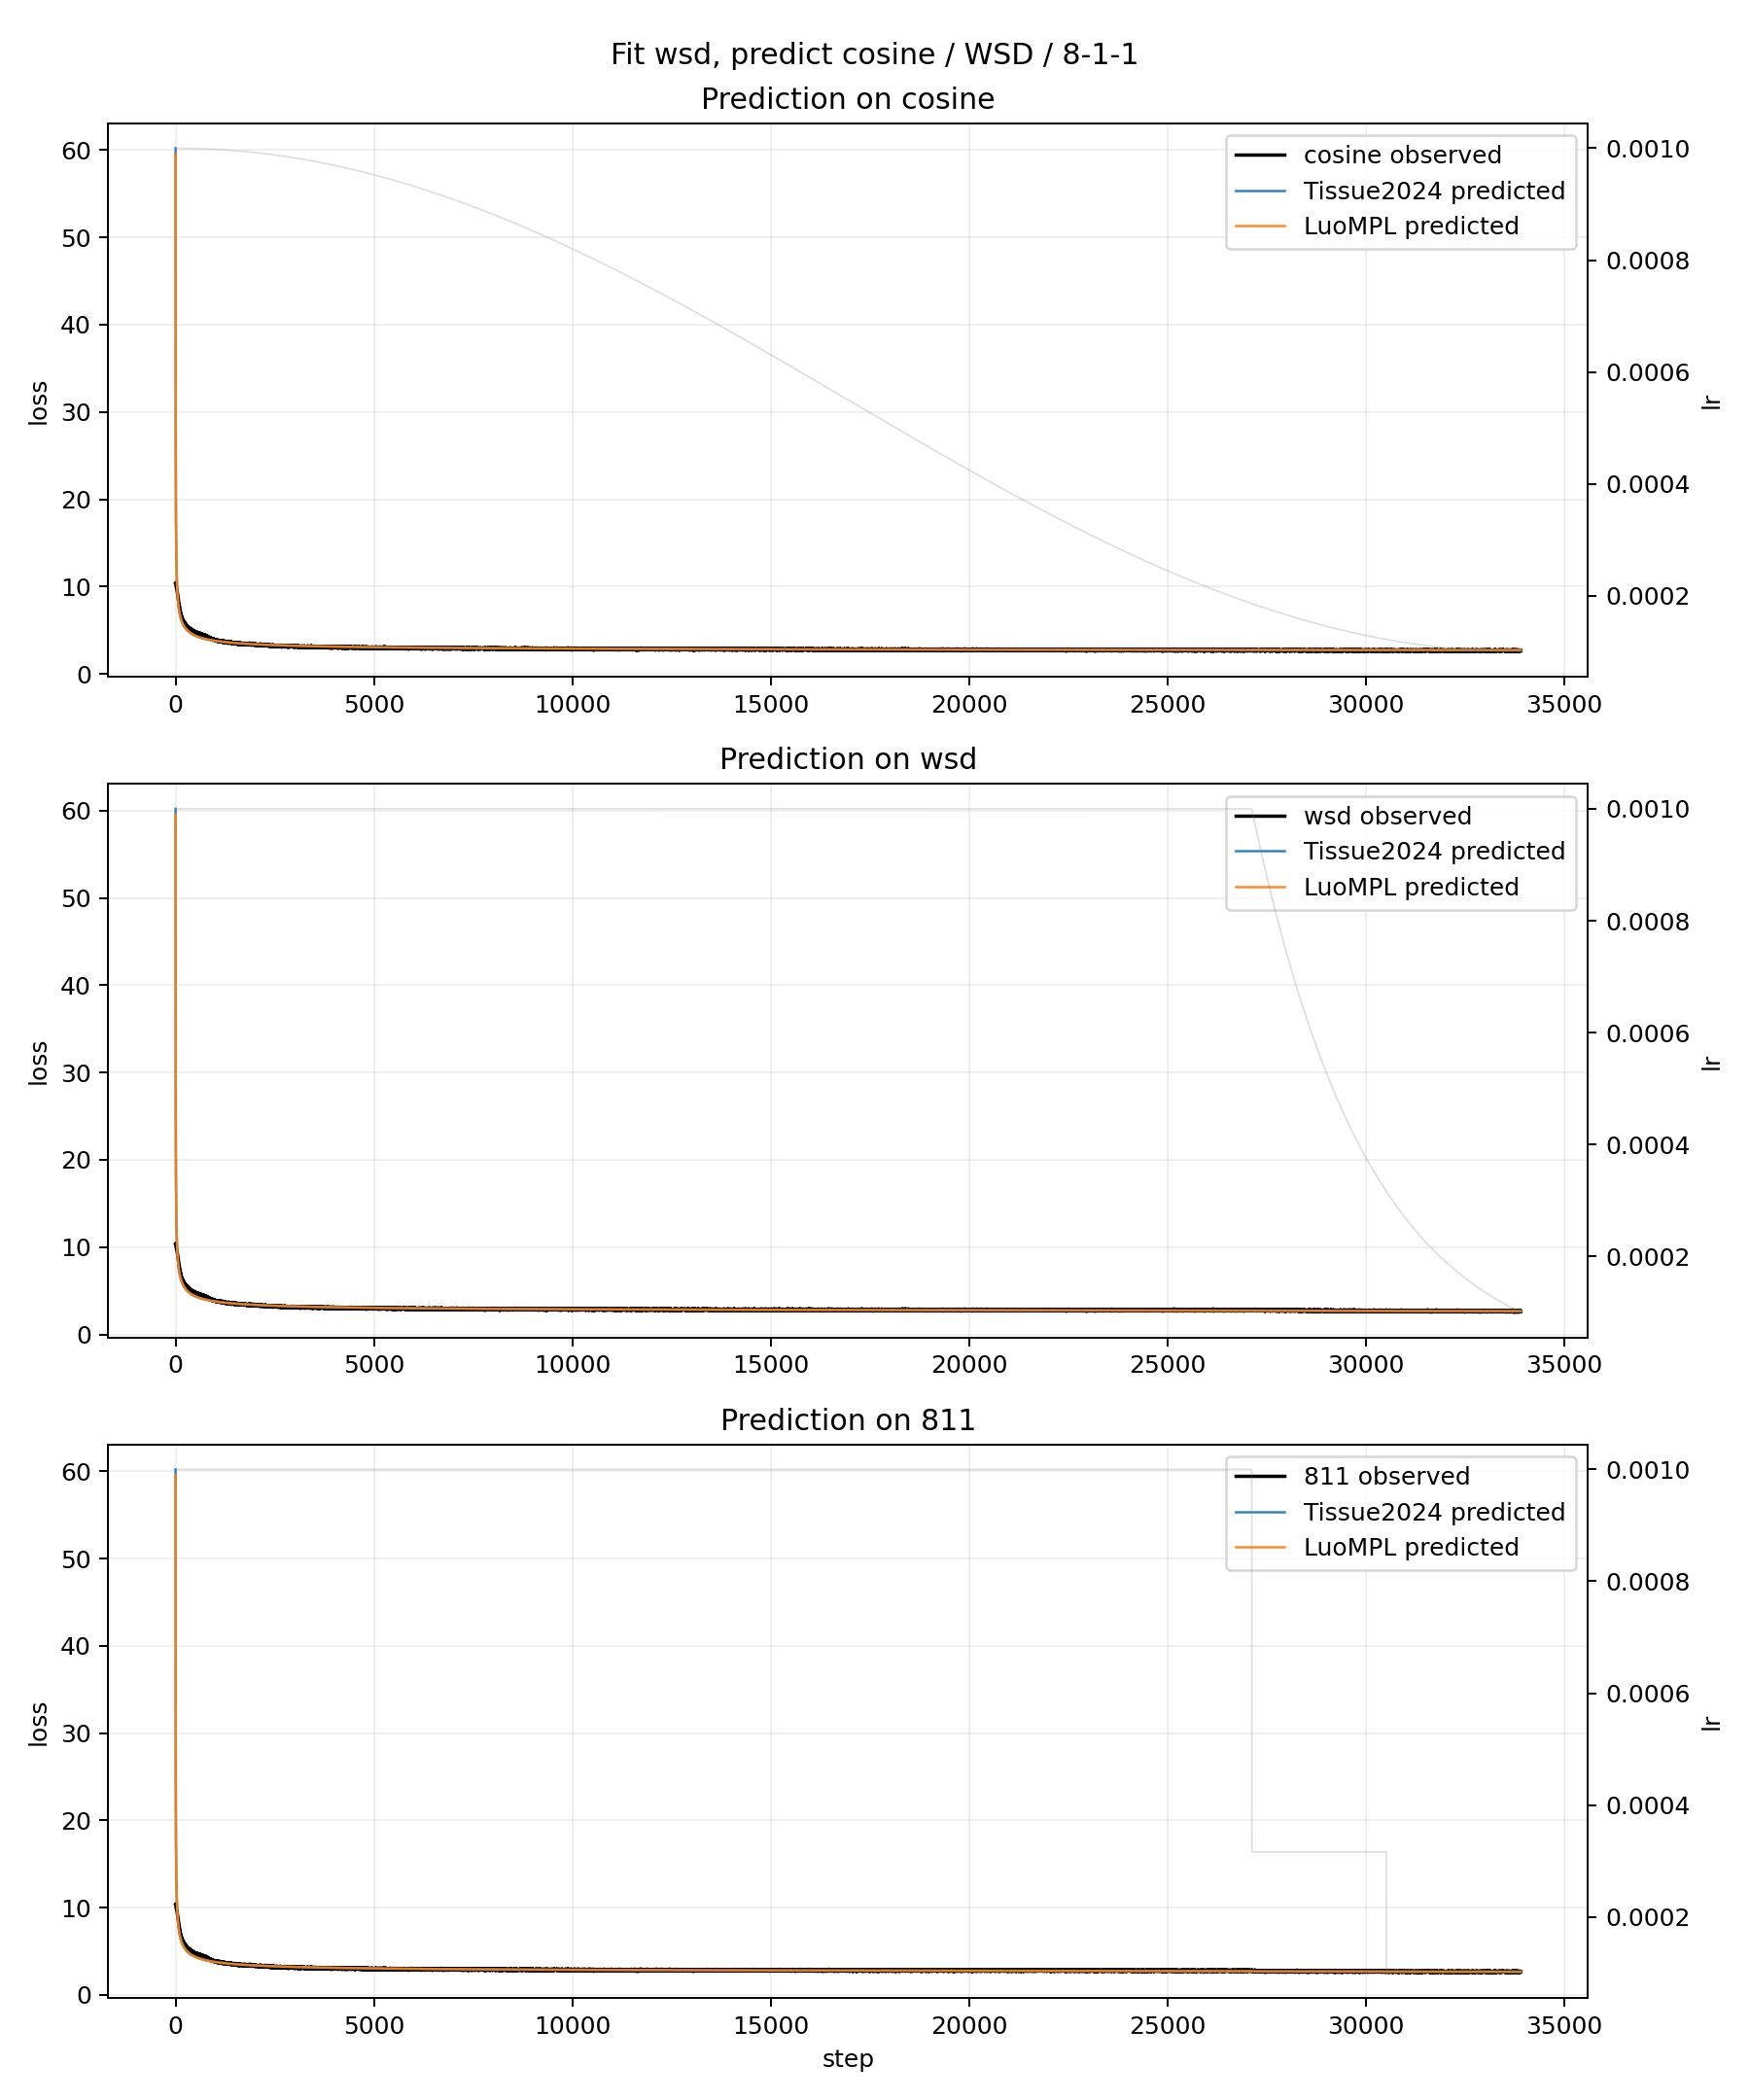

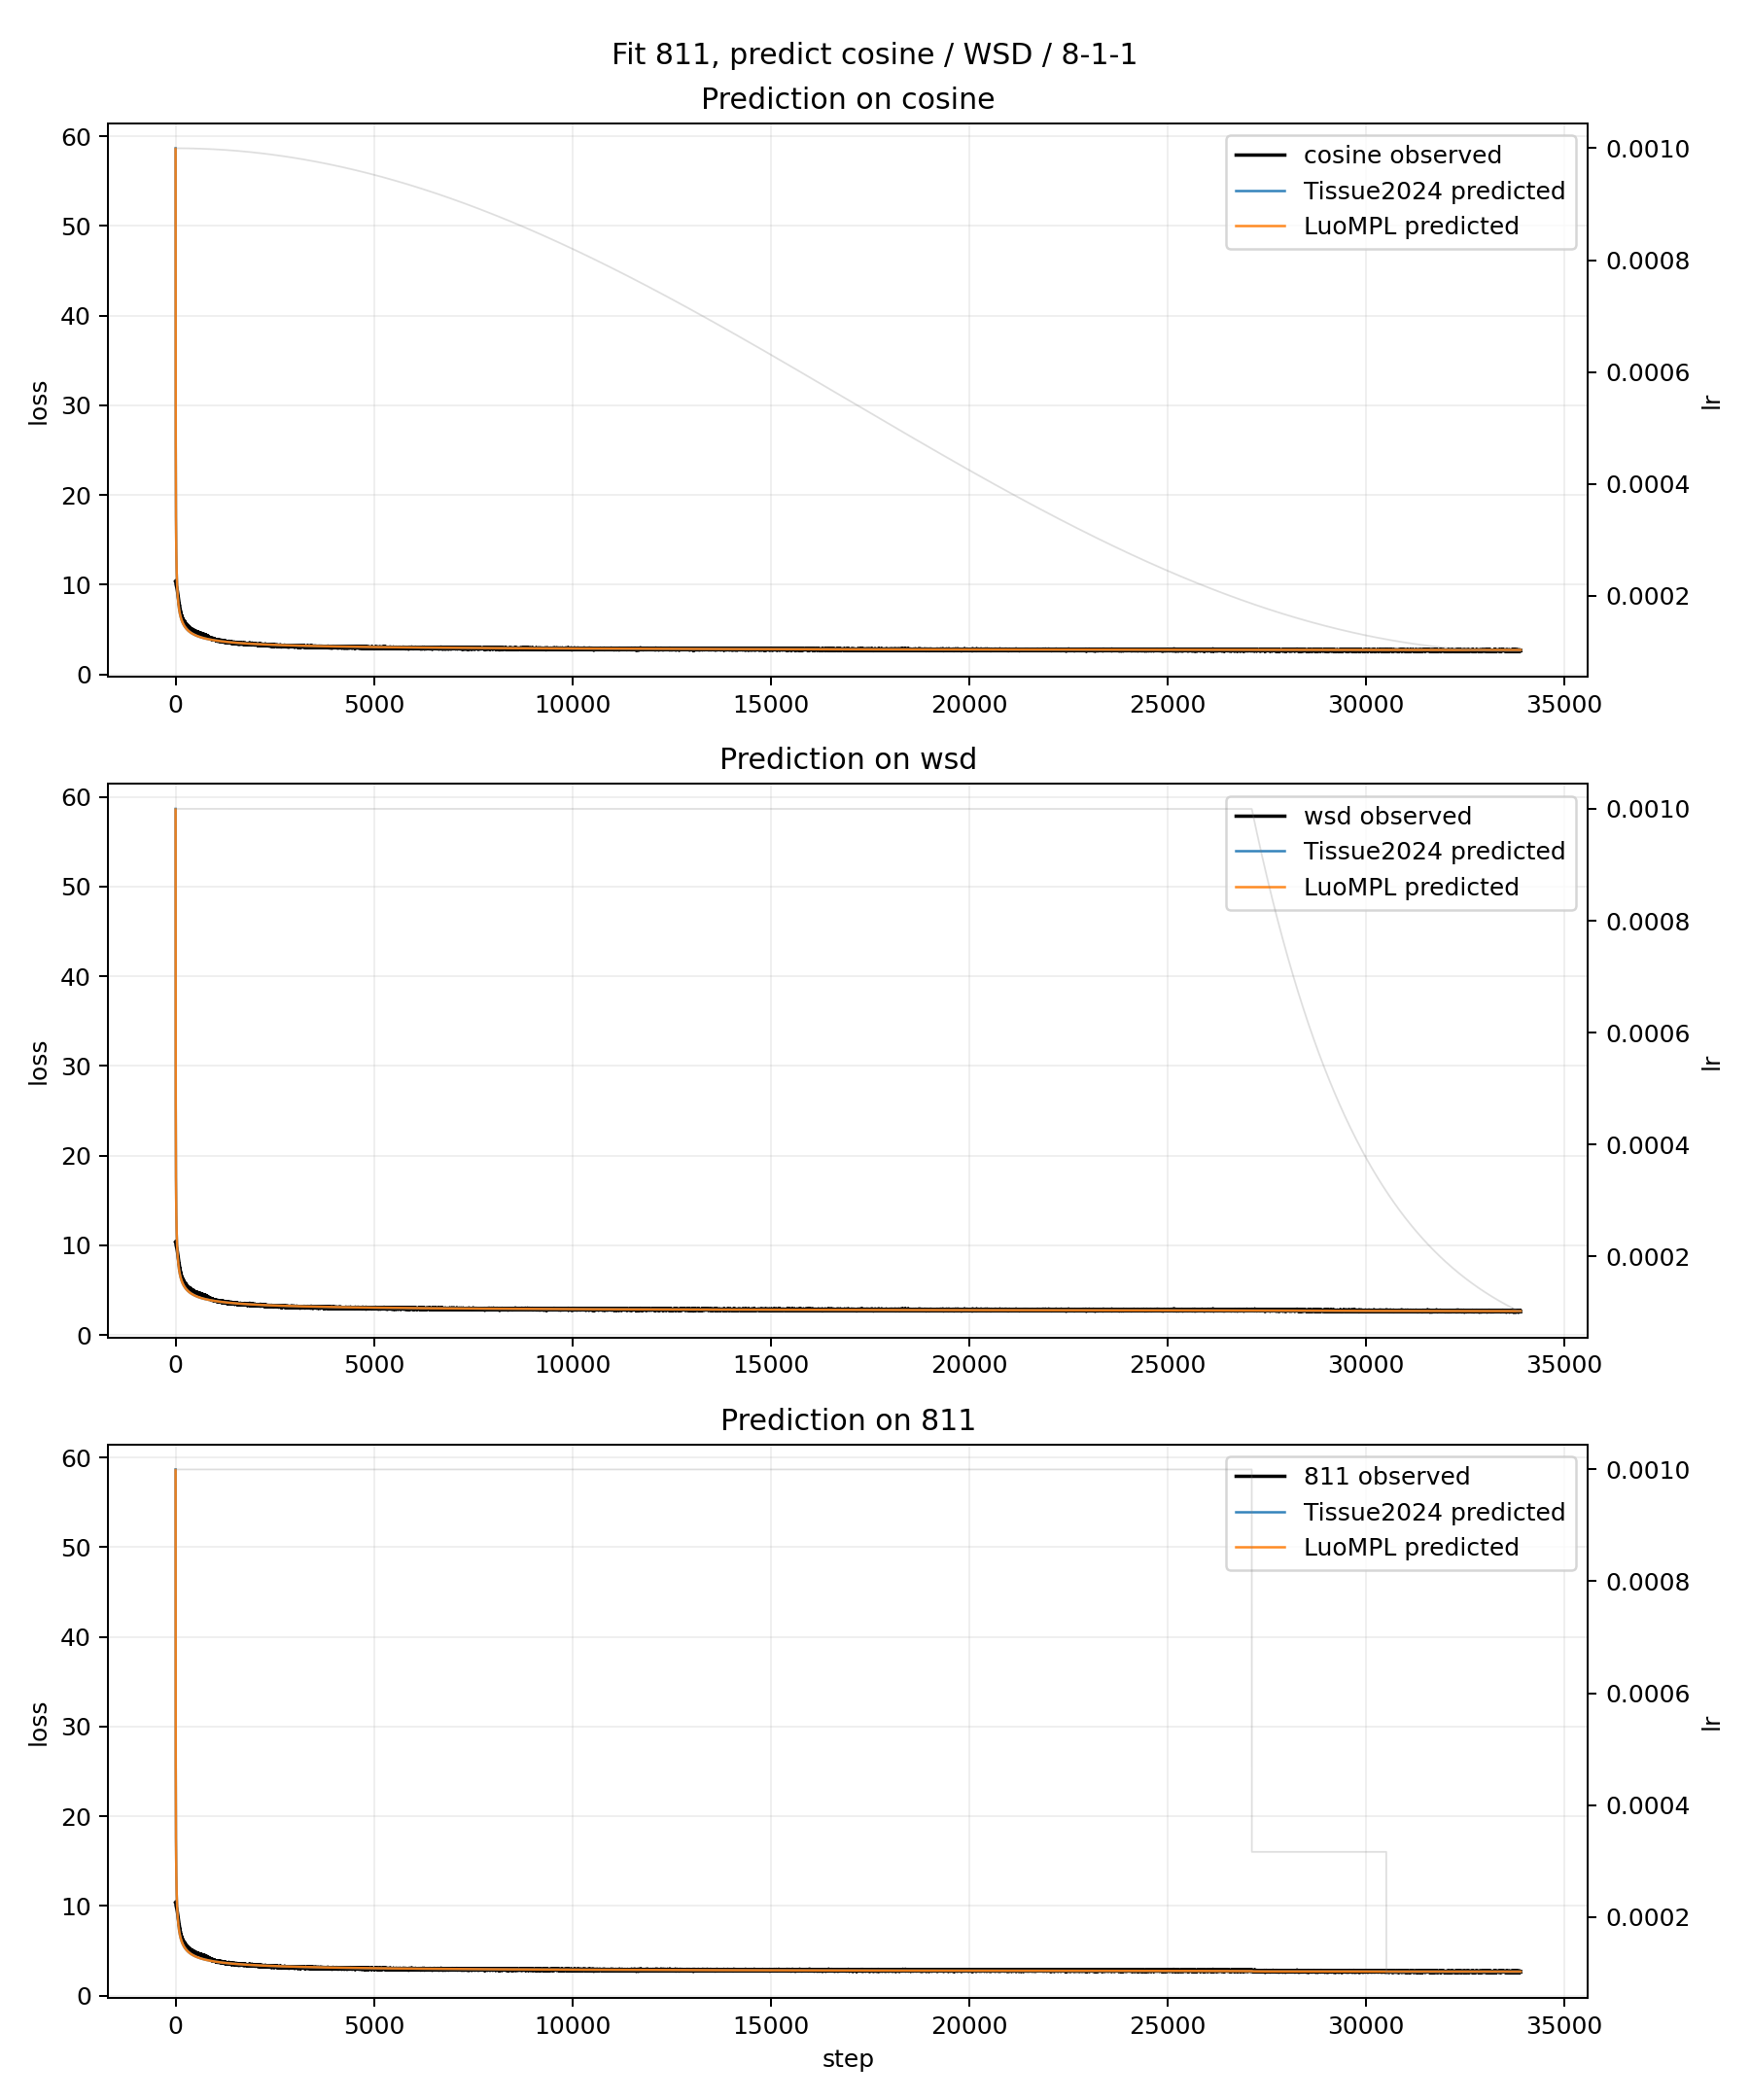

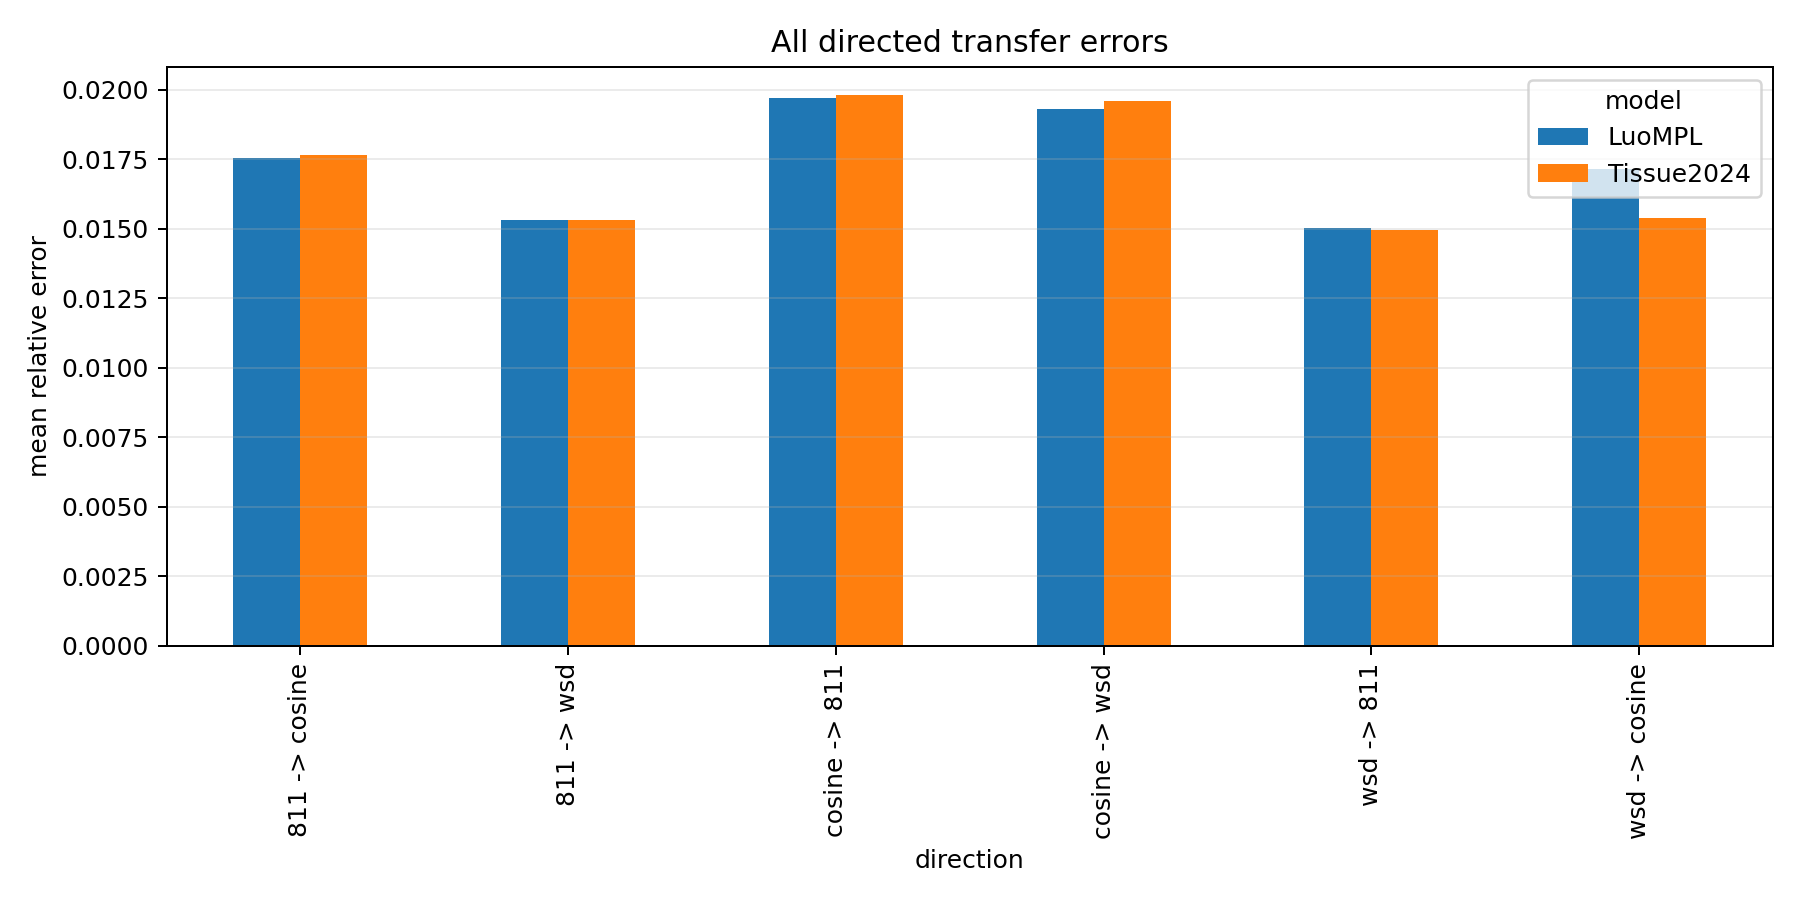

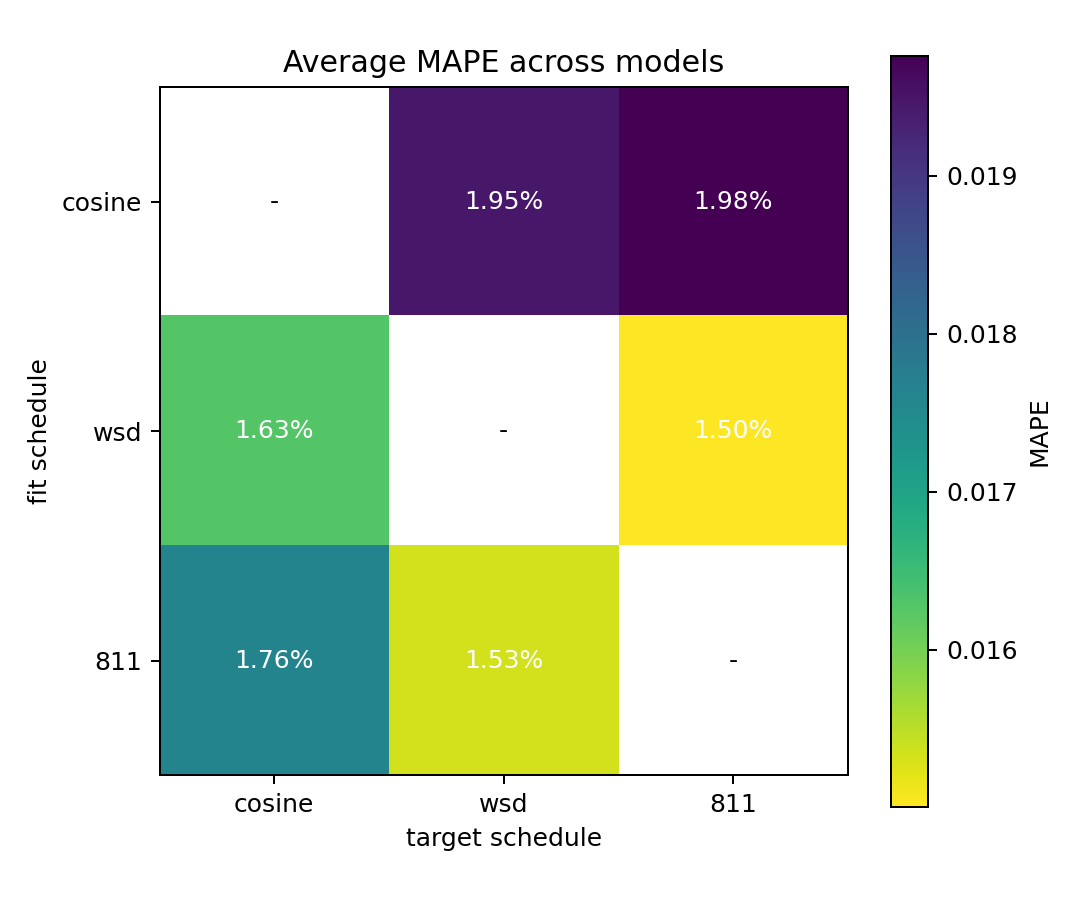

In [64]:
display(Image('task2_outputs/task2_wsd_fit_predictions.png'))
display(Image('task2_outputs/task2_811_fit_predictions.png'))
display(Image('task2_outputs/task2_transfer_comparison.png'))
display(Image('task2_outputs/task2_transfer_heatmap.png'))

## Part 3: 方法发展

这一部分单独比较我们提出的方法和复现基线。这里的 baseline 是 `Tissue2024` 和 `LuoMPL`，不再把传统 step-based power law 作为正式 baseline。方法命名如下：

- `Dev1-EffectiveTime`：方法1，effective-time power law。
- `Dev2-StepResidual`：方法2，step-based residual correction。
- `Dev3-EffectiveResidual`：方法3，effective-time residual correction。
- `Dev4-VelocityMatched`：方法4，loss velocity matching。
- `Dev5-HybridTissueMPL`：方法5，Hybrid Tissue + MultiPower correction。
- `Dev6-CurvatureMatched`：方法6，改进版 velocity + curvature matching。
- `Dev7-PowerExponential`：方法7，power law + exponential decay hybrid model。
- `Dev8-TimeEnsemble`：方法8，多时间坐标 ensemble。
- `Dev9-TissueVelocity`：方法9，将 velocity matching 加到 Tissue2024 主模型上。
- `Dev10-LuoMPLVelocity`：方法10，将 velocity matching 加到 LuoMPL 主模型上。
- `Dev11-PowerExpVelocity`：方法11，将 velocity matching 加到 PowerExponential 主模型上。

旧的 schedule-conditioned 方法因为跨调度外推不稳定，已经从正式方法发展比较中移除。所有 velocity matching 版本统一固定 `velocity_weight = 0.50`，不再使用源验证集或目标迁移结果进行权重选择。

In [65]:
development_metrics = pd.read_csv('task2_outputs/task2_development_metrics.csv')
development_metrics

,mae,rmse,mape,worst_relative_error,r2,final_abs_error,final_relative_error,experiment,model,fit_scheduler,target,role,selected_velocity_weight,direction
0,0.037306,0.049025,0.012861,0.067337,0.964941,0.021322,0.008058,cosine_fit,Tissue2024,cosine,cosine,fit_check,NaN,cosine -> cosine
1,0.056787,0.069550,0.019611,0.080386,0.922965,0.029700,0.011268,cosine_fit,Tissue2024,cosine,wsd,transfer,NaN,cosine -> wsd
2,0.039168,0.051882,0.013471,0.071861,0.960736,0.036646,0.013849,cosine_fit,LuoMPL,cosine,cosine,fit_check,NaN,cosine -> cosine
3,0.056016,0.068751,0.019314,0.077749,0.924725,0.004980,0.001889,cosine_fit,LuoMPL,cosine,wsd,transfer,NaN,cosine -> wsd
4,0.038677,0.050977,0.013314,0.069521,0.962094,0.031604,0.011943,cosine_fit,Dev1-EffectiveTime,cosine,cosine,fit_check,NaN,cosine -> cosine
5,0.054051,0.066949,0.018612,0.078300,0.928619,0.042050,0.015954,cosine_fit,Dev1-EffectiveTime,cosine,wsd,transfer,NaN,cosine -> wsd
6,0.037686,0.049952,0.012969,0.068769,0.963603,0.014358,0.005426,cosine_fit,Dev2-StepResidual,cosine,cosine,fit_check,NaN,cosine -> cosine
7,0.059854,0.072835,0.020839,0.091074,0.915517,0.128187,0.048634,cosine_fit,Dev2-StepResidual,cosine,wsd,transfer,NaN,cosine -> wsd
8,0.037710,0.050000,0.012976,0.068841,0.963534,0.014331,0.005416,cosine_fit,Dev3-EffectiveResidual,cosine,cosine,fit_check,NaN,cosine -> cosine
9,0.059923,0.072946,0.020864,0.091422,0.915259,0.129243,0.049035,cosine_fit,Dev3-EffectiveResidual,cosine,wsd,transfer,NaN,cosine -> wsd


In [66]:
development_metrics[development_metrics['role'] == 'transfer'][['model', 'direction', 'mape', 'rmse', 'mae', 'final_relative_error']].sort_values('mape')

,model,direction,mape,rmse,mae,final_relative_error
25,Dev11-PowerExpVelocity,cosine -> wsd,0.015887,0.056512,0.045505,0.011989
17,Dev7-PowerExponential,cosine -> wsd,0.015900,0.056545,0.045542,0.012032
11,Dev4-VelocityMatched,cosine -> wsd,0.018587,0.066946,0.053985,0.015999
15,Dev6-CurvatureMatched,cosine -> wsd,0.018599,0.066945,0.054016,0.015978
5,Dev1-EffectiveTime,cosine -> wsd,0.018612,0.066949,0.054051,0.015954
23,Dev10-LuoMPLVelocity,cosine -> wsd,0.019226,0.068636,0.055779,0.001924
21,Dev9-TissueVelocity,cosine -> wsd,0.019292,0.068805,0.055960,0.002330
3,LuoMPL,cosine -> wsd,0.019314,0.068751,0.056016,0.001889
1,Tissue2024,cosine -> wsd,0.019611,0.069550,0.056787,0.011268
13,Dev5-HybridTissueMPL,cosine -> wsd,0.019611,0.069550,0.056787,0.011268


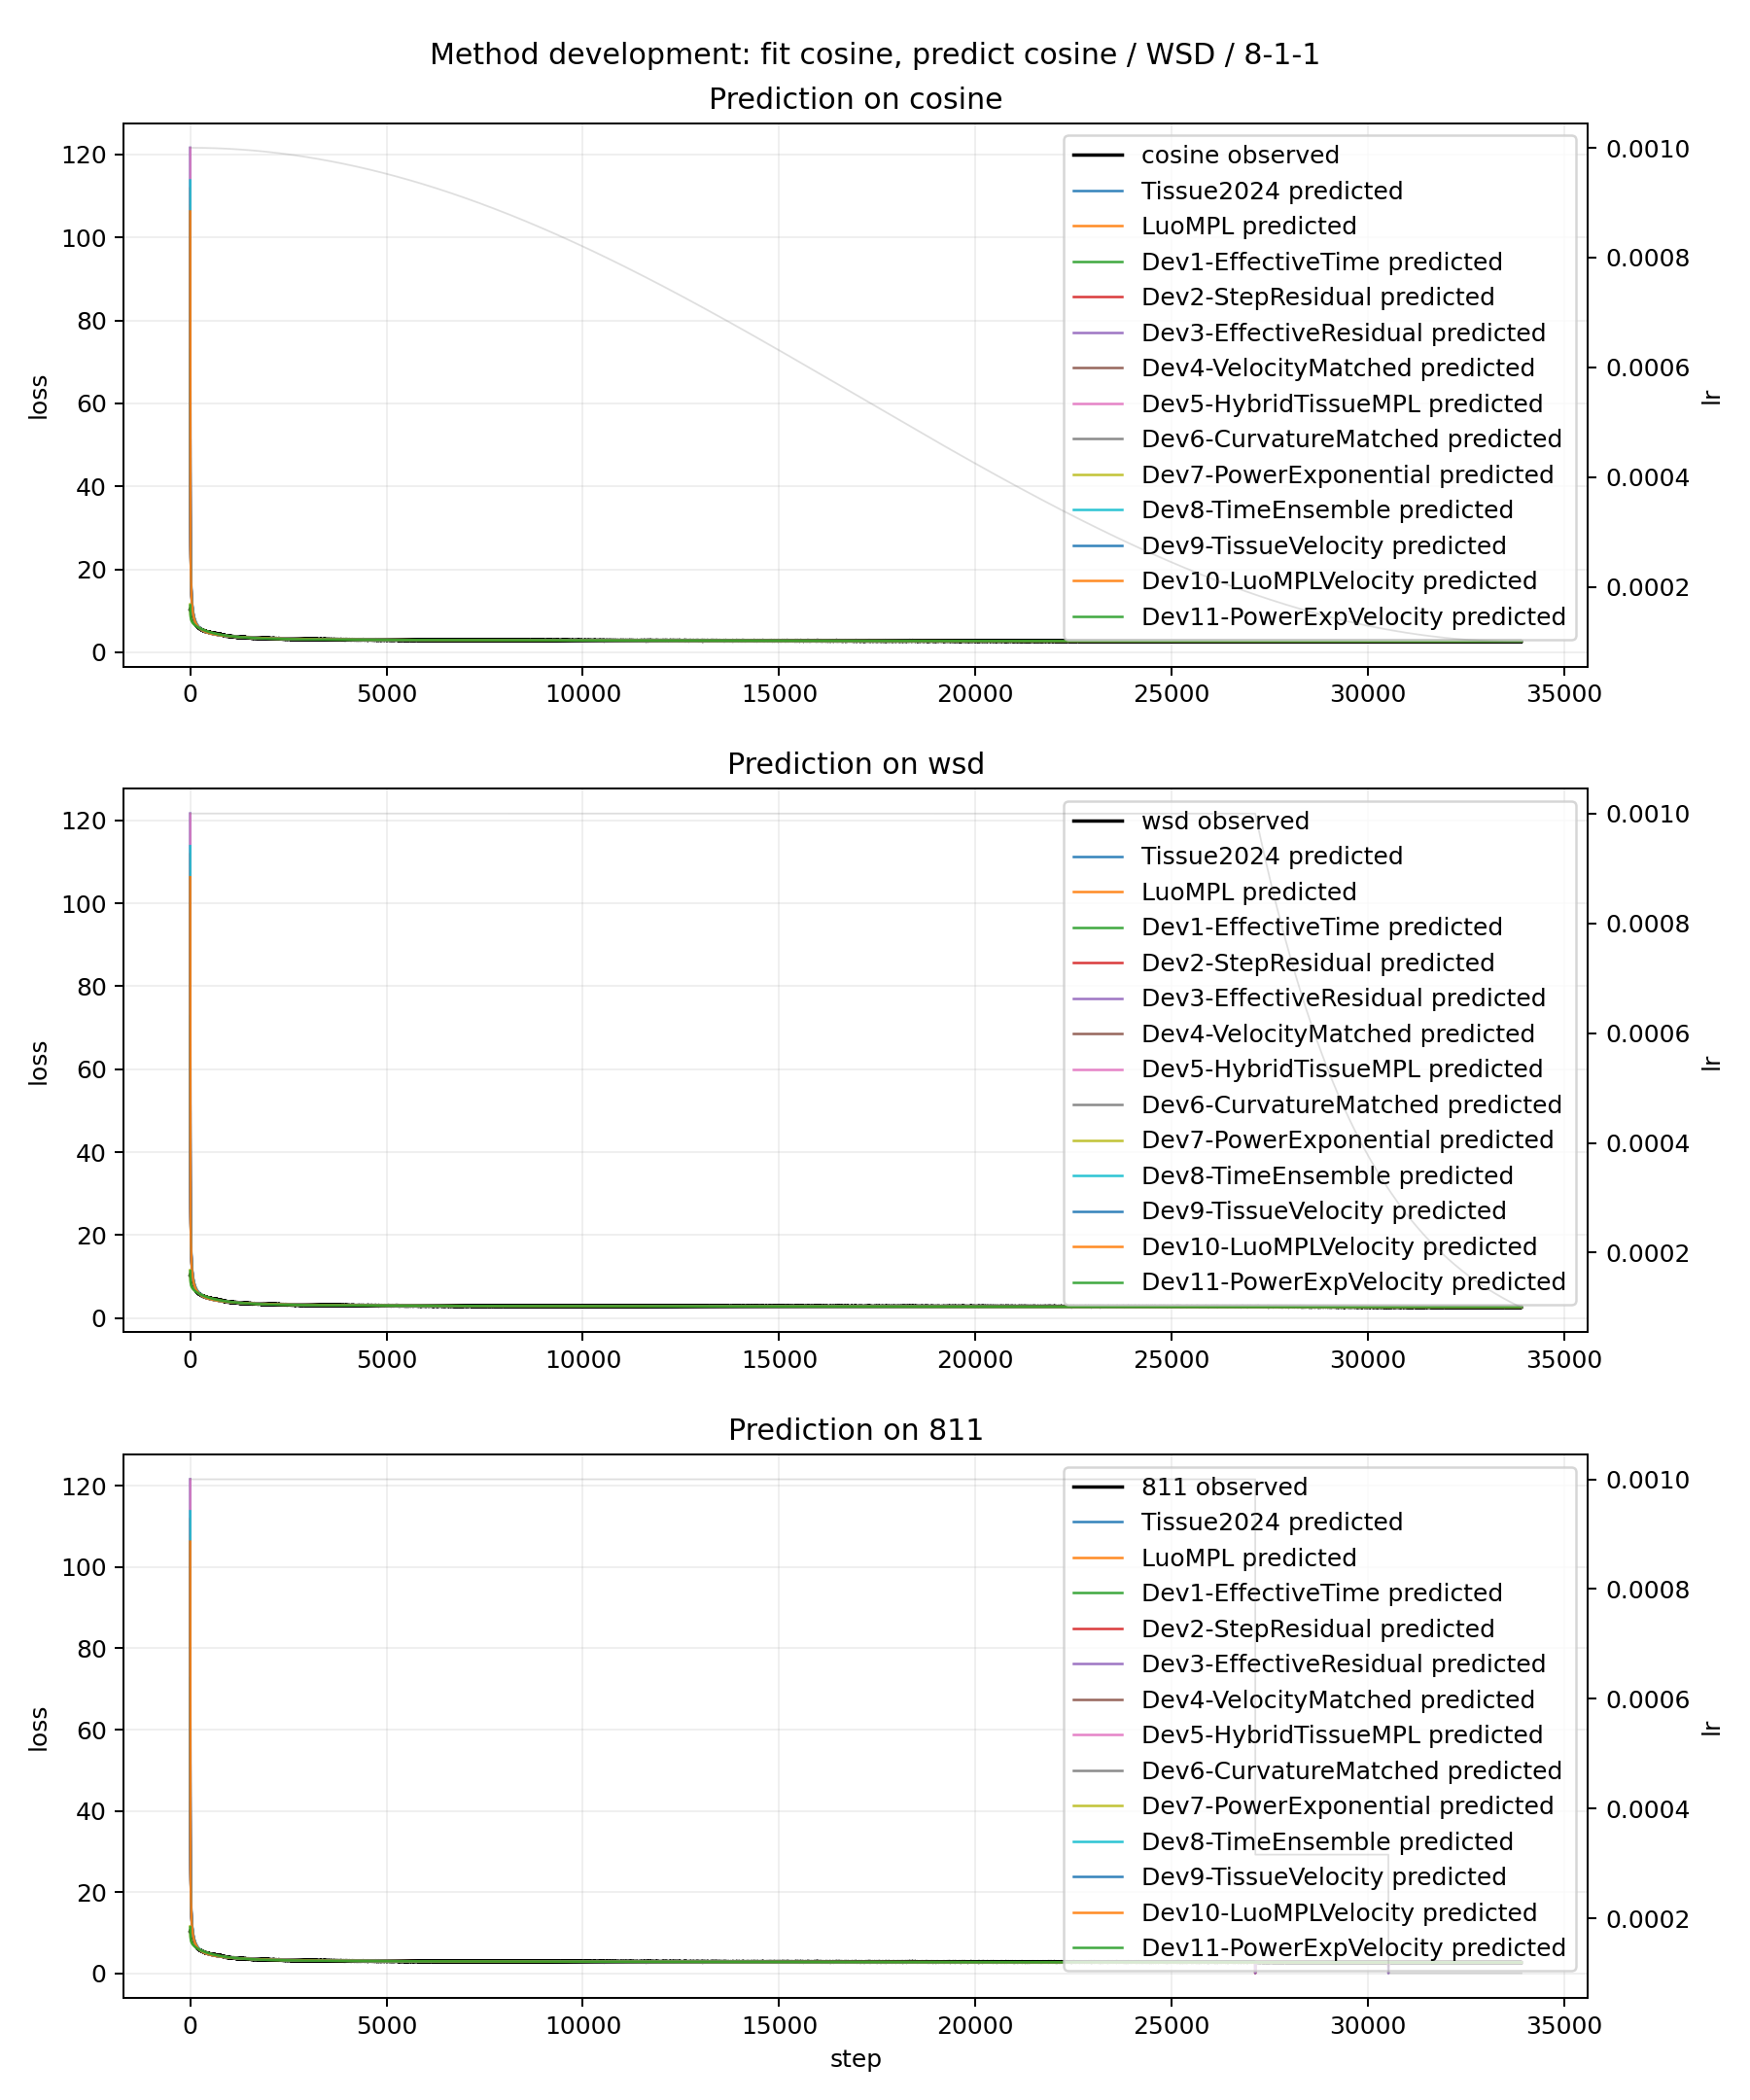

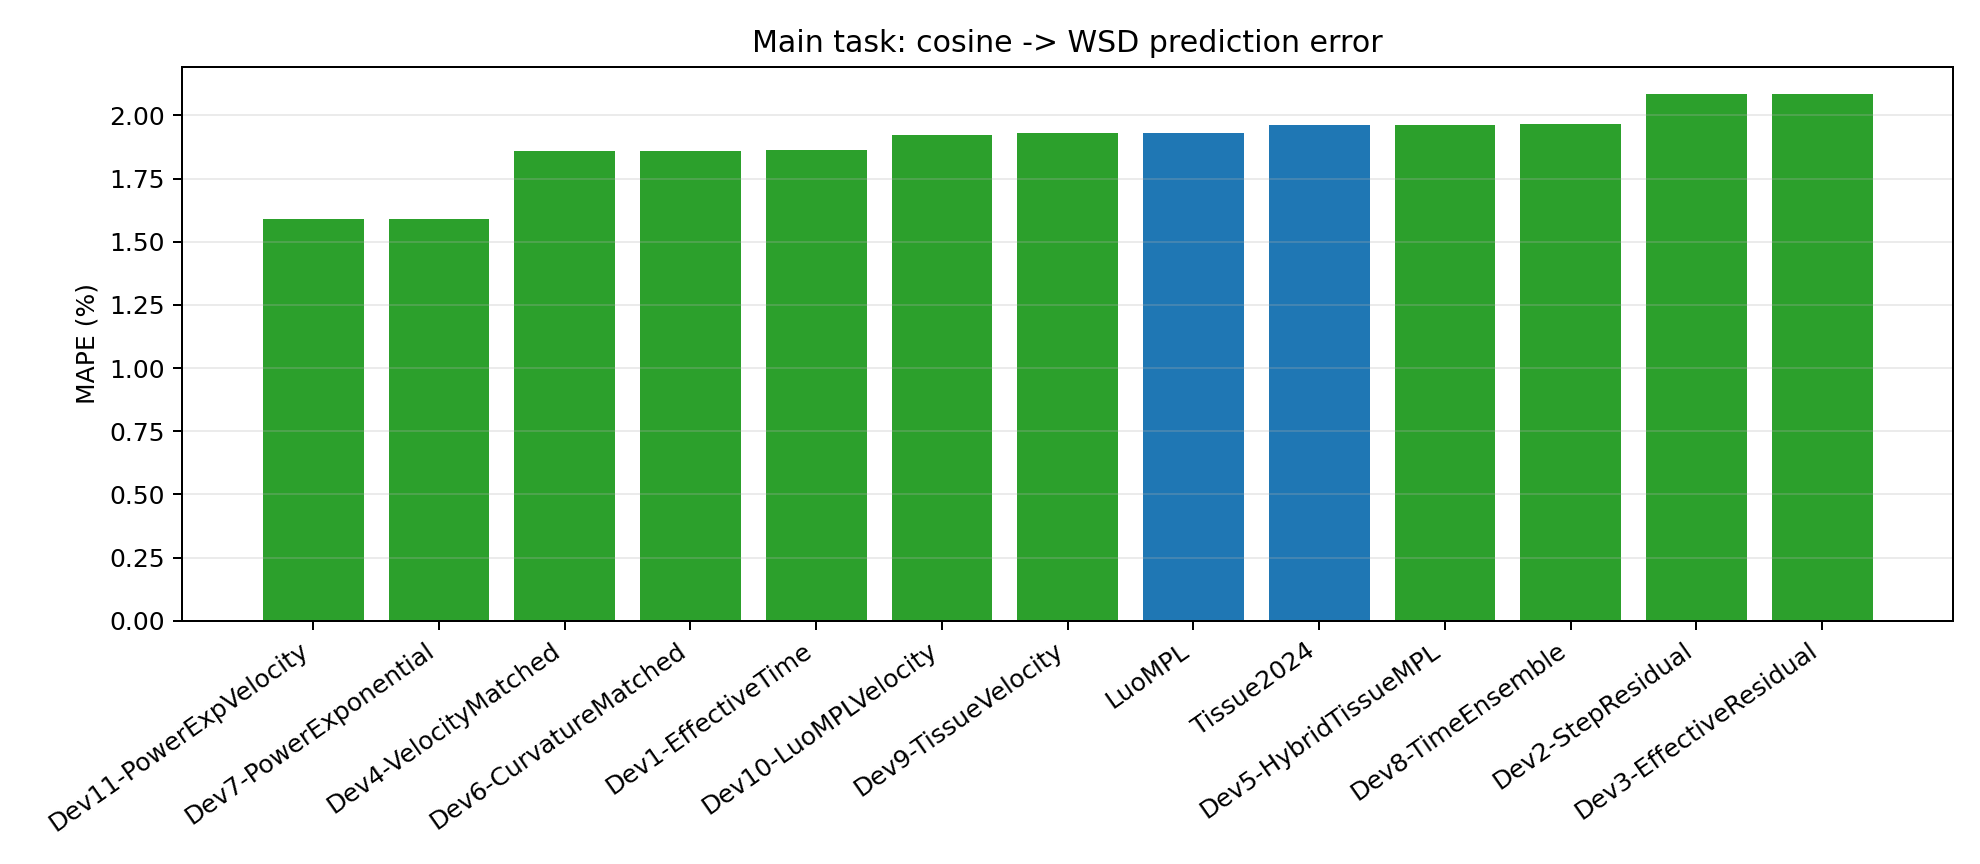

In [67]:
display(Image('task2_outputs/task2_method_development_predictions.png'))
display(Image('task2_outputs/task2_method_development_comparison.png'))

主要输出文件：

- 主任务复现：`task2_outputs/task2_main_metrics.csv`
- 迁移拓展：`task2_outputs/task2_extension_metrics.csv`
- 方法发展：`task2_outputs/task2_development_metrics.csv`
- 完整结果：`task2_outputs/task2_metrics.csv`
- 完整报告：`task2_outputs/task2_report.md`